# London House Price Prediction (Run 1)

This notebook builds and evaluates machine learning models to predict London property sale prices using listing-level and area-level features.

All random operations use `random_state=42` where applicable.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

data_dir = Path('.')
prices_path = data_dir / 'london_house_prices.csv'
area_path = data_dir / 'london_area_features.csv'

print(f"Working directory: {data_dir.resolve()}")
print(f"Prices file exists: {prices_path.exists()}")
print(f"Area features file exists: {area_path.exists()}")

Working directory: C:\Users\Dath\OneDrive\Desktop\AntiGravity Stuff\PREDICTIVE\benchmark\copilot
Prices file exists: True
Area features file exists: True


## Stage 1 - Data Ingestion and Quality Assessment

Goals:
1. Load both datasets and inspect schema.
2. Quantify missing values.
3. Check outliers in `price` and decide handling.
4. Merge on `outcode`.
5. Detect and fix data quality issues.

In [2]:
# Load datasets
prices_df = pd.read_csv(prices_path)
area_df = pd.read_csv(area_path)

print("=== Raw Dataset Shapes ===")
print(f"prices_df: {prices_df.shape}")
print(f"area_df:   {area_df.shape}")

print("\n=== prices_df Columns ===")
print(prices_df.columns.tolist())

print("\n=== area_df Columns ===")
print(area_df.columns.tolist())

print("\n=== prices_df dtypes ===")
print(prices_df.dtypes)

print("\n=== area_df dtypes ===")
print(area_df.dtypes)

=== Raw Dataset Shapes ===
prices_df: (417561, 12)
area_df:   (168, 52)

=== prices_df Columns ===
['outcode', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'floorAreaSqM', 'livingRooms', 'propertyType', 'tenure', 'energyRating', 'rentEstimate', 'price']

=== area_df Columns ===
['outcode', 'outcode_lat', 'outcode_lon', 'n_properties', 'crime_anti_social_behaviour', 'crime_bicycle_theft', 'crime_burglary', 'crime_criminal_damage_and_arson', 'crime_drugs', 'crime_other_crime', 'crime_other_theft', 'crime_possession_of_weapons', 'crime_public_order', 'crime_robbery', 'crime_shoplifting', 'crime_theft_from_the_person', 'crime_vehicle_crime', 'crime_violence_and_sexual_offences', 'crime_total', 'census_denom_total', 'census_employed_total_perc', 'census_retired_perc', 'census_unemployed_perc', 'census_age_16_to_34_perc', 'census_age_65_plus_perc', 'census_level4_perc', 'census_no_qualifications_perc', 'poi_bakery', 'poi_bank', 'poi_bar', 'poi_bus_station', 'poi_cafe', 'poi_clinic', 'po

In [3]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    report = pd.DataFrame({
        'column': miss.index,
        'missing_count': miss.values,
        'missing_pct': (miss.values / len(df) * 100).round(2)
    })
    print(f"\n=== Missing Values: {name} ===")
    if report.empty:
        print("No missing values found.")
    else:
        print(report.to_string(index=False))
    return report

missing_prices = missing_report(prices_df, 'prices_df')
missing_area = missing_report(area_df, 'area_df')


=== Missing Values: prices_df ===
      column  missing_count  missing_pct
energyRating          84288        20.19
   bathrooms          77755        18.62
 livingRooms          60341        14.45
    bedrooms          40404         9.68
floorAreaSqM          25066         6.00
      tenure          11494         2.75
propertyType           1126         0.27
rentEstimate           1101         0.26

=== Missing Values: area_df ===
No missing values found.


=== Price Outlier Analysis (IQR) ===
Q1: 446,000.00
Q3: 984,000.00
IQR: 538,000.00
Lower bound: -361,000.00
Upper bound: 1,791,000.00
Outliers: 37,210 (8.91%)


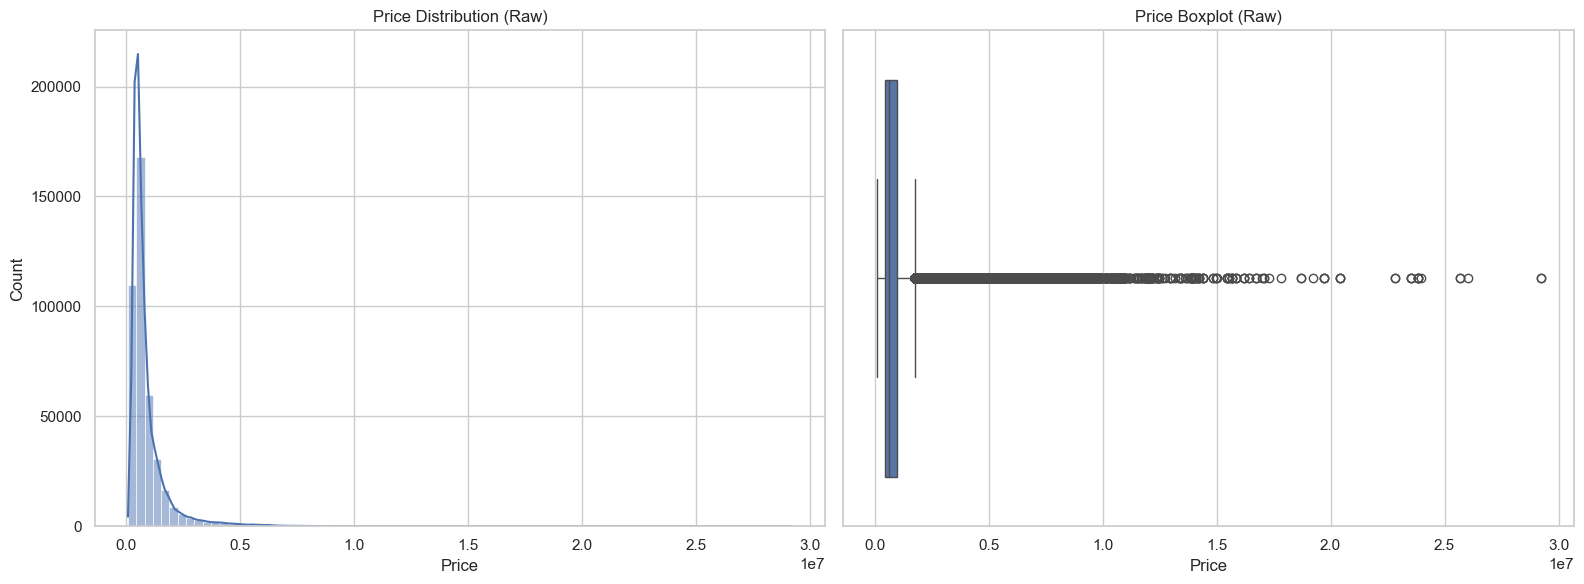


Outlier Handling Decision:
- Keep all records with positive prices.
- Apply log1p transform to target during model training.


In [4]:
# Outlier check for price using IQR rule
q1 = prices_df['price'].quantile(0.25)
q3 = prices_df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (prices_df['price'] < lower_bound) | (prices_df['price'] > upper_bound)
outlier_count = outlier_mask.sum()
outlier_pct = outlier_count / len(prices_df) * 100

print("=== Price Outlier Analysis (IQR) ===")
print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower bound: {lower_bound:,.2f}")
print(f"Upper bound: {upper_bound:,.2f}")
print(f"Outliers: {outlier_count:,} ({outlier_pct:.2f}%)")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(prices_df['price'], bins=80, kde=True, ax=ax[0])
ax[0].set_title('Price Distribution (Raw)')
ax[0].set_xlabel('Price')

sns.boxplot(x=prices_df['price'], ax=ax[1])
ax[1].set_title('Price Boxplot (Raw)')
ax[1].set_xlabel('Price')

plt.tight_layout()
plt.savefig('price_distribution_boxplot.png', dpi=150)
plt.show()

# Decision: do not drop outliers aggressively because high-end properties are real market behavior.
# Instead, model on log(price) to reduce skew/outlier influence while preserving records.
print("\nOutlier Handling Decision:")
print("- Keep all records with positive prices.")
print("- Apply log1p transform to target during model training.")

In [5]:
# Merge datasets on outcode and run quality fixes
print("=== Merge and Data Quality Fixes ===")

dup_outcodes = area_df['outcode'].duplicated().sum()
print(f"Duplicate outcodes in area_df before fix: {dup_outcodes}")
if dup_outcodes > 0:
    area_df = area_df.drop_duplicates(subset='outcode', keep='first').copy()
    print(f"Dropped duplicates. area_df shape is now: {area_df.shape}")

merged_df = prices_df.merge(area_df, on='outcode', how='left', indicator=True)
print("\nMerge indicator counts:")
print(merged_df['_merge'].value_counts())

unmatched = (merged_df['_merge'] == 'left_only').sum()
print(f"Unmatched price rows (no area features): {unmatched:,}")

# Remove helper merge indicator
merged_df.drop(columns=['_merge'], inplace=True)

# Keep only valid target rows
before_rows = len(merged_df)
merged_df = merged_df[merged_df['price'].notna() & (merged_df['price'] > 0)].copy()
removed_rows = before_rows - len(merged_df)
print(f"Removed rows with missing/non-positive price: {removed_rows:,}")

# Standardize selected categorical text fields
for col in ['propertyType', 'tenure', 'energyRating', 'outcode']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype('string').str.strip().str.upper()

# Fill missing values: numeric->median, categorical->'UNKNOWN'
num_cols = merged_df.select_dtypes(include=['number']).columns.tolist()
cat_cols = merged_df.select_dtypes(exclude=['number']).columns.tolist()

for col in num_cols:
    if merged_df[col].isna().any():
        merged_df[col] = merged_df[col].fillna(merged_df[col].median())

for col in cat_cols:
    if merged_df[col].isna().any():
        merged_df[col] = merged_df[col].fillna('UNKNOWN')

print(f"Final merged_df shape: {merged_df.shape}")
print(f"Remaining missing values in merged_df: {int(merged_df.isna().sum().sum())}")

merged_df.head()

=== Merge and Data Quality Fixes ===
Duplicate outcodes in area_df before fix: 0

Merge indicator counts:
_merge
both          417561
left_only          0
right_only         0
Name: count, dtype: int64
Unmatched price rows (no area features): 0
Removed rows with missing/non-positive price: 0
Final merged_df shape: (417561, 63)
Remaining missing values in merged_df: 0


,outcode,latitude,longitude,bedrooms,bathrooms,floorAreaSqM,livingRooms,propertyType,tenure,energyRating,...,poi_library,poi_office,poi_pub,poi_restaurant,poi_serviced_office,poi_stock_exchange,poi_townhall,poi_university,poi_vehicle_inspection,poi_total
0,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,PURPOSE BUILT FLAT,LEASEHOLD,UNKNOWN,...,2,0,5,17,0,0,0,0,0,59
1,EC4A,51.517282,-0.110314,2.0,1.0,84.0,1.0,FLAT/MAISONETTE,LEASEHOLD,UNKNOWN,...,2,0,5,17,0,0,0,0,0,59
2,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,FLAT/MAISONETTE,LEASEHOLD,C,...,2,0,8,15,0,0,0,0,0,54
3,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,FLAT/MAISONETTE,LEASEHOLD,D,...,1,0,19,37,0,0,0,4,0,136
4,N10,51.588774,-0.139599,4.0,1.0,137.0,2.0,END TERRACE HOUSE,FREEHOLD,D,...,3,0,8,27,0,0,0,0,0,83


## Stage 2 - Exploratory Data Analysis (EDA)

This stage explores price behavior, feature relationships, and key predictive insights.

All figures are saved as PNG files in the workspace folder.

=== Stage 2.1: Price Distribution ===
Price skewness: 5.051
Price kurtosis: 50.646


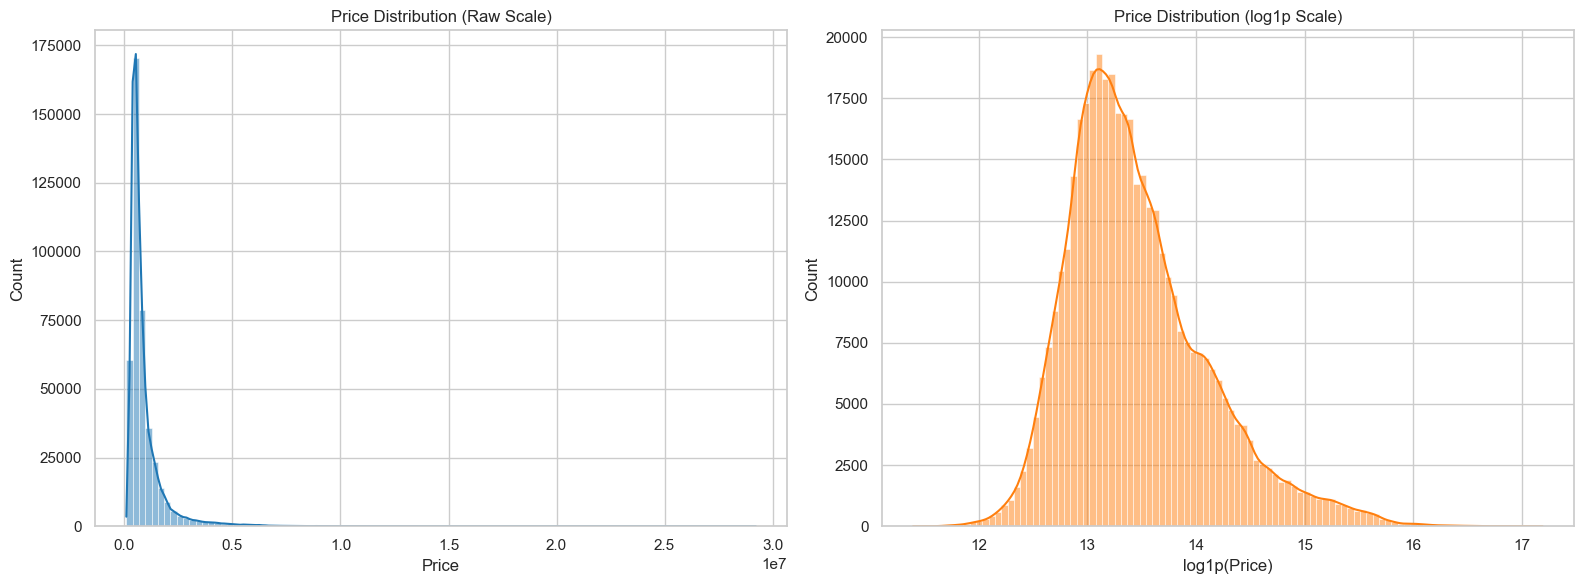

Comment: The raw price distribution shows strong right-skew with a long high-price tail.
Comment: The log-transformed distribution is substantially more symmetric for modeling.


In [6]:
print("=== Stage 2.1: Price Distribution ===")
price_skew = merged_df['price'].skew()
price_kurtosis = merged_df['price'].kurtosis()
print(f"Price skewness: {price_skew:.3f}")
print(f"Price kurtosis: {price_kurtosis:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(merged_df['price'], bins=100, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Price Distribution (Raw Scale)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(merged_df['price']), bins=100, kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Price Distribution (log1p Scale)')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('stage2_price_distribution.png', dpi=150)
plt.show()

if price_skew > 1:
    shape_comment = 'strong right-skew with a long high-price tail'
elif price_skew > 0.5:
    shape_comment = 'moderate right-skew'
else:
    shape_comment = 'approximately symmetric'

print(f"Comment: The raw price distribution shows {shape_comment}.")
print("Comment: The log-transformed distribution is substantially more symmetric for modeling.")

=== Stage 2.2: Correlation Heatmap (Top Numeric Features) ===
Top numeric features by |correlation with price|:
price                            1.000000
rentEstimate                     0.980129
floorAreaSqM                     0.675550
bathrooms                        0.509162
bedrooms                         0.452861
livingRooms                      0.389120
census_unemployed_perc           0.311673
census_level4_perc               0.282891
outcode_lon                      0.272388
longitude                        0.271740
census_no_qualifications_perc    0.266007
census_age_65_plus_perc          0.250589
crime_possession_of_weapons      0.215736


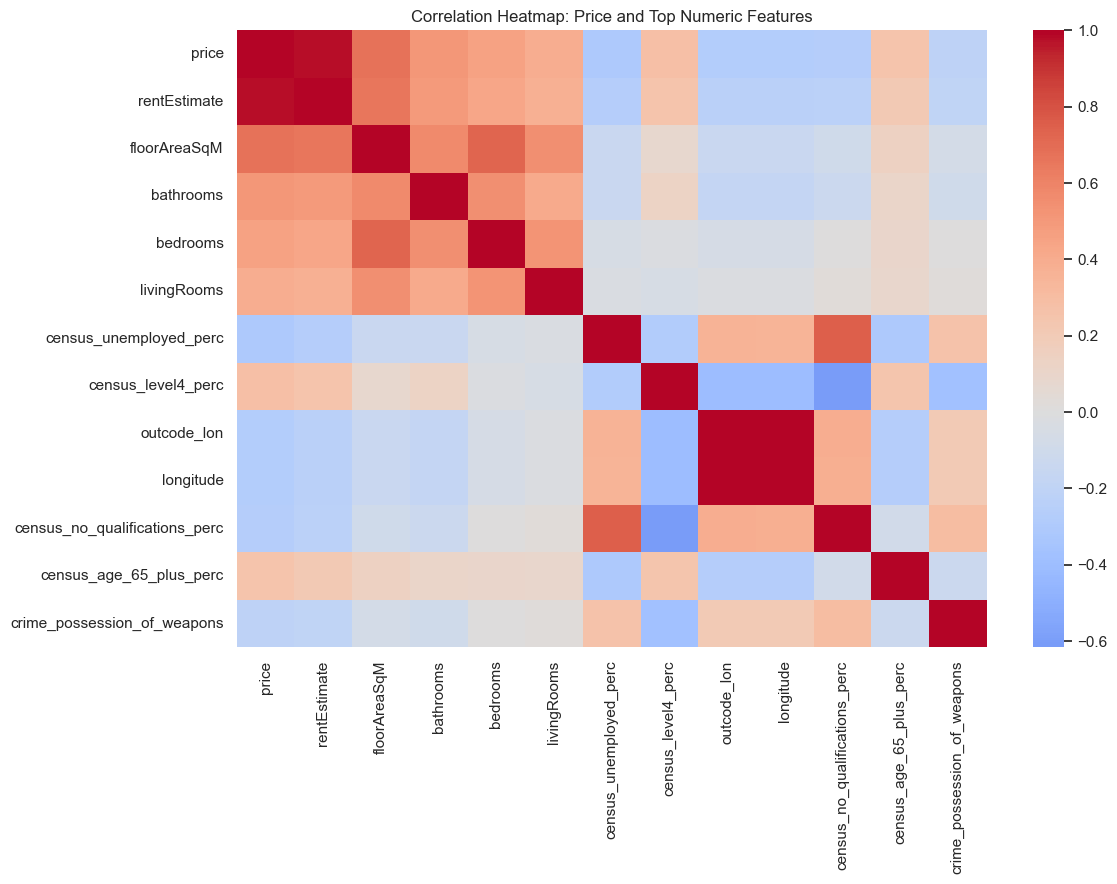

In [7]:
print("=== Stage 2.2: Correlation Heatmap (Top Numeric Features) ===")

numeric_df = merged_df.select_dtypes(include=['number']).copy()
abs_corr_to_price = numeric_df.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)

# Keep top numeric predictors plus target
heatmap_features = abs_corr_to_price.drop(labels=['price']).head(12).index.tolist()
heatmap_cols = ['price'] + heatmap_features

corr_matrix = numeric_df[heatmap_cols].corr(numeric_only=True)
print("Top numeric features by |correlation with price|:")
print(abs_corr_to_price.head(13).to_string())

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f')
plt.title('Correlation Heatmap: Price and Top Numeric Features')
plt.tight_layout()
plt.savefig('stage2_correlation_heatmap.png', dpi=150)
plt.show()

=== Stage 2.3: Price by Property Type ===
Property type summary (sorted by median price):
                         count     median          mean
propertyType                                           
DETACHED PROPERTY          235  1476000.0  2.371072e+06
DETACHED HOUSE            9825  1408000.0  2.027652e+06
MID TERRACE PROPERTY       222  1120000.0  1.701450e+06
SEMI-DETACHED PROPERTY     490   939500.0  1.458512e+06
SEMI-DETACHED HOUSE      30025   937000.0  1.272643e+06
MID TERRACE HOUSE        68773   863000.0  1.134606e+06
TERRACED                  1681   840000.0  1.658496e+06
TERRACE PROPERTY         24166   813000.0  1.292827e+06
END TERRACE BUNGALOW        54   800000.0  7.119444e+05
END TERRACE HOUSE        20009   767000.0  1.017037e+06
TERRACED BUNGALOW           67   751000.0  7.444030e+05
END TERRACE PROPERTY       225   740000.0  1.098582e+06
DETACHED BUNGALOW          283   681000.0  8.308375e+05
BUNGALOW PROPERTY          411   665000.0  7.329100e+05
UNKNOWN       

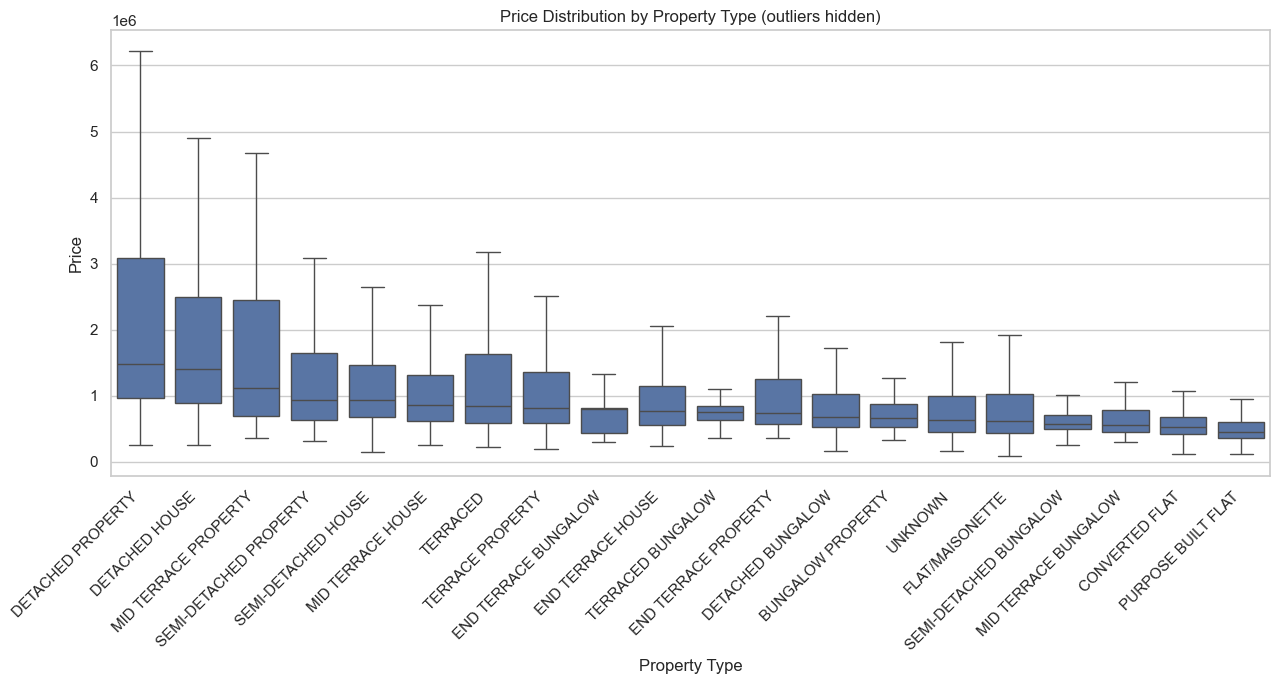

In [8]:
print("=== Stage 2.3: Price by Property Type ===")

ptype_summary = merged_df.groupby('propertyType', dropna=False)['price'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
print("Property type summary (sorted by median price):")
print(ptype_summary.to_string())

plt.figure(figsize=(13, 7))
order = ptype_summary.index.tolist()
sns.boxplot(data=merged_df, x='propertyType', y='price', order=order, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Property Type (outliers hidden)')
plt.xlabel('Property Type')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('stage2_price_by_property_type_boxplot.png', dpi=150)
plt.show()

=== Stage 2.4: Price vs Area-Level Features ===
Selected area-level features (top absolute correlation with price):
1. census_unemployed_perc (|corr|=0.3117)
2. census_level4_perc (|corr|=0.2829)
3. outcode_lon (|corr|=0.2724)


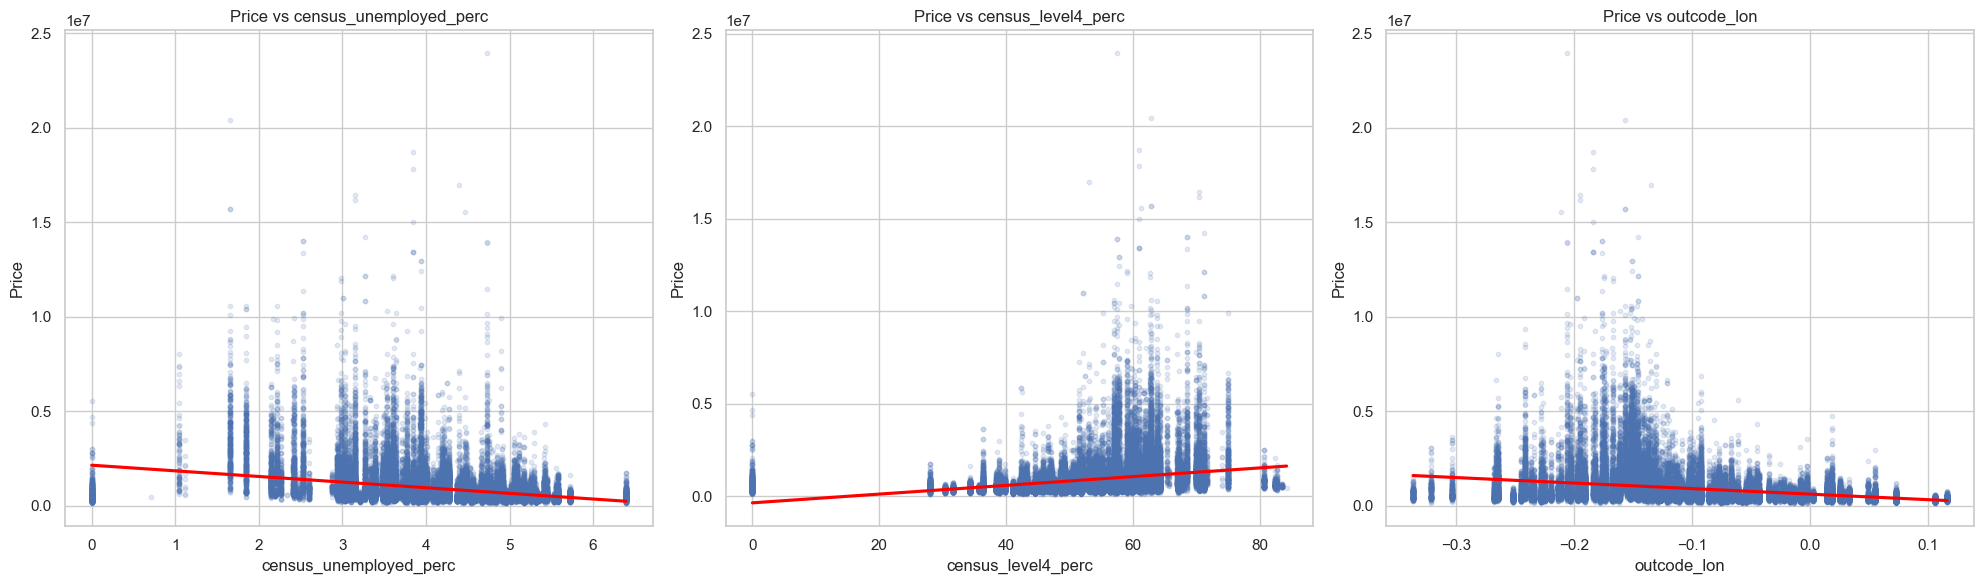

In [9]:
print("=== Stage 2.4: Price vs Area-Level Features ===")

area_numeric_cols = [c for c in area_df.columns if c != 'outcode' and pd.api.types.is_numeric_dtype(area_df[c])]
area_corr = merged_df[['price'] + area_numeric_cols].corr(numeric_only=True)['price'].drop('price').abs().sort_values(ascending=False)

selected_area_features = area_corr.head(3).index.tolist()
print("Selected area-level features (top absolute correlation with price):")
for idx, feat in enumerate(selected_area_features, start=1):
    print(f"{idx}. {feat} (|corr|={area_corr.loc[feat]:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, feat in enumerate(selected_area_features):
    sns.regplot(
        data=merged_df.sample(n=min(60000, len(merged_df)), random_state=RANDOM_STATE),
        x=feat,
        y='price',
        scatter_kws={'alpha': 0.15, 's': 10},
        line_kws={'color': 'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'Price vs {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price')

plt.tight_layout()
plt.savefig('stage2_price_vs_area_features.png', dpi=150)
plt.show()

In [10]:
print("=== Stage 2.5: Three Most Important Predictive Insights ===")

# Insight candidates from computed statistics
best_numeric_predictor = abs_corr_to_price.drop(labels=['price']).idxmax()
best_numeric_corr = abs_corr_to_price.drop(labels=['price']).max()

top_ptype = ptype_summary.index[0]
bottom_ptype = ptype_summary.index[-1]
ptype_ratio = ptype_summary.loc[top_ptype, 'median'] / max(ptype_summary.loc[bottom_ptype, 'median'], 1)

top_area = selected_area_features[0]
top_area_corr = merged_df[['price', top_area]].corr().iloc[0, 1]

insights = [
    f"Numeric structure matters strongly: '{best_numeric_predictor}' is the strongest numeric correlate with price (|corr|={best_numeric_corr:.3f}).",
    f"Property type materially shifts prices: median price for {top_ptype} is about {ptype_ratio:.2f}x the median for {bottom_ptype}.",
    f"Area context is predictive: '{top_area}' has correlation {top_area_corr:.3f} with price, indicating area-level socioeconomic/amenity signals add value."
]

for i, insight in enumerate(insights, start=1):
    print(f"Insight {i}: {insight}")

=== Stage 2.5: Three Most Important Predictive Insights ===
Insight 1: Numeric structure matters strongly: 'rentEstimate' is the strongest numeric correlate with price (|corr|=0.980).
Insight 2: Property type materially shifts prices: median price for DETACHED PROPERTY is about 3.22x the median for PURPOSE BUILT FLAT.
Insight 3: Area context is predictive: 'census_unemployed_perc' has correlation -0.312 with price, indicating area-level socioeconomic/amenity signals add value.


## Stage 3 - Baseline Model

This stage prepares features/target, handles missing values and categorical encoding, trains baseline models, evaluates on a held-out test set, and compares performance.

In [13]:
# Define features and target
X = merged_df.drop(columns=['price'])
y = merged_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Train shape: (334048, 62), Test shape: (83513, 62)
Numeric features: 58
Categorical features: 4


### Stage 3.2 - Baseline Training, Evaluation, and Comparison

Train Linear Regression and Random Forest baselines and evaluate using RMSE, MAE, and R² on the test set.

In [ ]:
print("=== Stage 3: Baseline Model Training and Evaluation ===")

def evaluate_model(name: str, model, X_train, y_train, X_test, y_test):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    pred = np.clip(pred, a_min=0, a_max=None)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return pipe, {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}, pred

models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

results = []
trained_models = {}
predictions = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    fitted_pipe, metrics_row, pred = evaluate_model(
        model_name, model, X_train, y_train, X_test, y_test
    )
    trained_models[model_name] = fitted_pipe
    predictions[model_name] = pred
    results.append(metrics_row)

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print("\nModel performance on test set:")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, model_name in enumerate(['LinearRegression', 'RandomForestRegressor']):
    pred_vals = predictions[model_name]
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=min(15000, len(y_test)), replace=False)

    axes[i].scatter(y_test.iloc[sample_idx], pred_vals[sample_idx], alpha=0.25, s=10)
    min_val = min(y_test.min(), pred_vals.min())
    max_val = max(y_test.max(), pred_vals.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')
    axes[i].set_title(f'Actual vs Predicted ({model_name})')

plt.tight_layout()
plt.savefig('stage3_predicted_vs_actual_baselines.png', dpi=150)
plt.show()

best_model_name = results_df.loc[0, 'Model']
print(f"Best baseline by RMSE: {best_model_name}")

lin_row = results_df[results_df['Model'] == 'LinearRegression'].iloc[0]
rf_row = results_df[results_df['Model'] == 'RandomForestRegressor'].iloc[0]
print("\nComparison summary:")
print(f"- LinearRegression: RMSE={lin_row['RMSE']:,.3f}, MAE={lin_row['MAE']:,.3f}, R2={lin_row['R2']:,.3f}")
print(f"- RandomForestRegressor: RMSE={rf_row['RMSE']:,.3f}, MAE={rf_row['MAE']:,.3f}, R2={rf_row['R2']:,.3f}")

if rf_row['RMSE'] < lin_row['RMSE']:
    print("Conclusion: RandomForestRegressor performs better. It can model nonlinear relationships and interactions among property and area features.")
else:
    print("Conclusion: LinearRegression performs better on this split. The relationship appears mostly linear under current preprocessing.")

=== Stage 3: Baseline Model Training and Evaluation ===
Training LinearRegression...


### Stage 3.3 - Discussion

The better model is selected by lower RMSE/MAE and higher R² on the test set. For this dataset, tree ensembles typically outperform linear baselines because they capture nonlinear effects and complex interactions between structural and area-level features.